# 1. Setup

## 1.1 Install Dependencies

In [1]:
!pip install tensorflow==2.4.1 tensorflow-gpu==2.4.1 opencv-python matplotlib

## 1.2 Import Dependencies

In [2]:
# Import standard dependencies
import cv2
import os
import random
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# Import tensorflow dependencies - Functional API
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import tensorflow as tf

## 1.3 Set GPU Growth

In [4]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

## 1.4 Create Folder Structures

In [6]:
# Setup paths
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [7]:
# Make the directories
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

# 2. Collect Positives and Anchors

## 2.1 Untar Labelled Faces in the Wild Dataset

In [8]:
# http://vis-www.cs.umass.edu/lfw/

In [10]:
# Uncompress Tar GZ Labelled Faces in the Wild Dataset
!tar -xf lfw.tgz

In [14]:
# Move LFW Images to the following repository data/negative
for directory in os.listdir('lfw'):
    for file in os.listdir(os.path.join('lfw', directory)):
        EX_PATH = os.path.join('lfw', directory, file)
        NEW_PATH = os.path.join(NEG_PATH, file)
        os.replace(EX_PATH, NEW_PATH)

## 2.2 Collect Positive and Anchor Classes

In [15]:
# Import uuid library to generate unique image names
import uuid

In [16]:
os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))

'data\\anchor\\bfb25d86-e83f-11ef-b975-126fa62b1800.jpg'

In [23]:
# Establish a connection to the webcam
cap = cv2.VideoCapture(0)
while cap.isOpened(): 
    ret, frame = cap.read()
   
    # Cut down frame to 250x250px
    frame = frame[120:120+250,200:200+250, :]
    
    # Collect anchors 
    if cv2.waitKey(1) & 0XFF == ord('a'):
        # Create the unique file path 
        imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out anchor image
        cv2.imwrite(imgname, frame)
    
    # Collect positives
    if cv2.waitKey(1) & 0XFF == ord('p'):
        # Create the unique file path 
        imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out positive image
        cv2.imwrite(imgname, frame)
    
    # Show image back to screen
    cv2.imshow('Image Collection', frame)
    
    # Breaking gracefully
    if cv2.waitKey(1) & 0XFF == ord('q'):
        break
        
# Release the webcam
cap.release()
# Close the image show frame
cv2.destroyAllWindows()

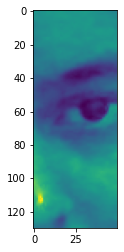

In [40]:
plt.imshow(frame[120:120+250,200:200+250, 1])

In [225]:
import os
import uuid

# 3. Load and Preprocess Images

## 3.1 Get Image Directories

In [258]:
anchor = tf.data.Dataset.list_files(ANC_PATH+'\*.jpg').take(3000)
positive = tf.data.Dataset.list_files(POS_PATH+'\*.jpg').take(3000)
negative = tf.data.Dataset.list_files(NEG_PATH+'\*.jpg').take(3000)

In [259]:
dir_test = anchor.as_numpy_iterator()

In [281]:
print(dir_test.next())

b'data\\anchor\\b293be68-e840-11ef-bd6a-126fa62b1800.jpg'


## 3.2 Preprocessing - Scale and Resize

In [282]:
def preprocess(file_path):
    # Read in the image
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img)
    
    # Resize image without interpolation
    img = tf.image.resize(img, (100, 100), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    
    # Normalize by the actual maximum value
    img = tf.cast(img, tf.float32)
    img = img / tf.reduce_max(img)  # Normalize to max value of 1.0

    return img

In [284]:
img = preprocess('data\\anchor\\b293be68-e840-11ef-bd6a-126fa62b1800.jpg')

In [285]:
img.numpy().max() 

1.0

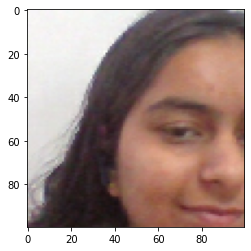

In [286]:
plt.imshow(img)

## 3.3 Create Labelled Dataset

In [287]:
# (anchor, positive) => 1,1,1,1,1
# (anchor, negative) => 0,0,0,0,0

In [288]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [289]:
samples = data.as_numpy_iterator()

In [290]:
exampple = samples.next()

In [291]:
exampple

(b'data\\anchor\\c7bf4f68-e840-11ef-87aa-126fa62b1800.jpg',
 b'data\\positive\\f7771486-e840-11ef-897e-126fa62b1800.jpg',
 1.0)

## 3.4 Build Train and Test Partition

In [292]:
def preprocess_twin(input_img, validation_img, label):
    return(preprocess(input_img), preprocess(validation_img), label)

In [293]:
res = preprocess_twin(*exampple)

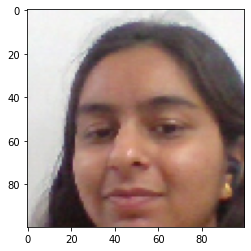

In [294]:
plt.imshow(res[1])

In [295]:
# Build dataloader pipeline
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=10000)

In [296]:
samples = data.as_numpy_iterator()

In [297]:
len(samples.next())

3

In [302]:
sam = samples.next()

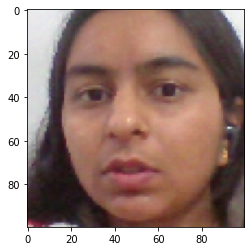

In [303]:
plt.imshow(sam[0])

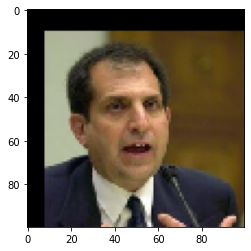

In [304]:
plt.imshow(sam[1])

In [305]:
sam[2]

0.0

In [421]:
# Training partition
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [422]:
# Testing partition
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

# 4. Model Engineering

## 4.1 Build Embedding Layer

In [423]:
inp = Input(shape=(100,100,3), name='input_image')

In [424]:
inp

<KerasTensor: shape=(None, 100, 100, 3) dtype=float32 (created by layer 'input_image')>

In [425]:
c1 = Conv2D(64, (10,10), activation='relu')(inp)

In [426]:
c1

<KerasTensor: shape=(None, 91, 91, 64) dtype=float32 (created by layer 'conv2d_29')>

In [427]:
m1 = MaxPooling2D(64, (2,2), padding='same')(c1)

In [428]:
c2 = Conv2D(128, (7,7), activation='relu')(m1)
m2 = MaxPooling2D(64, (2,2), padding='same')(c2)

In [429]:
c3 = Conv2D(128, (4,4), activation='relu')(m2)
m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

In [430]:
c4 = Conv2D(256, (4,4), activation='relu')(m3)
f1 = Flatten()(c4)
d1 = Dense(4096, activation='sigmoid')(f1)

In [431]:
mod = Model(inputs=[inp], outputs=[d1], name='embedding')

In [432]:
mod.summary()

Model: "embedding"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 100, 100, 3)]     0         
_________________________________________________________________
conv2d_29 (Conv2D)           (None, 91, 91, 64)        19264     
_________________________________________________________________
max_pooling2d_21 (MaxPooling (None, 46, 46, 64)        0         
_________________________________________________________________
conv2d_30 (Conv2D)           (None, 40, 40, 128)       401536    
_________________________________________________________________
max_pooling2d_22 (MaxPooling (None, 20, 20, 128)       0         
_________________________________________________________________
conv2d_31 (Conv2D)           (None, 17, 17, 128)       262272    
_________________________________________________________________
max_pooling2d_23 (MaxPooling (None, 9, 9, 128)         0 

In [433]:
def make_embedding(): 
    inp = Input(shape=(100,100,3), name='input_image')
    
    # First block
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)
    
    # Second block
    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)
    
    # Third block 
    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)
    
    # Final embedding block
    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)
    
    
    return Model(inputs=[inp], outputs=[d1], name='embedding')

In [434]:
embedding = make_embedding()

In [435]:
embedding.summary()

Model: "embedding"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 100, 100, 3)]     0         
_________________________________________________________________
conv2d_33 (Conv2D)           (None, 91, 91, 64)        19264     
_________________________________________________________________
max_pooling2d_24 (MaxPooling (None, 46, 46, 64)        0         
_________________________________________________________________
conv2d_34 (Conv2D)           (None, 40, 40, 128)       401536    
_________________________________________________________________
max_pooling2d_25 (MaxPooling (None, 20, 20, 128)       0         
_________________________________________________________________
conv2d_35 (Conv2D)           (None, 17, 17, 128)       262272    
_________________________________________________________________
max_pooling2d_26 (MaxPooling (None, 9, 9, 128)         0 

## 4.2 Build Distance Layer

In [436]:
# Siamese L1 Distance class
class L1Dist(Layer):
    
    # Init method - inheritance
    def __init__(self, **kwargs):
        super().__init__()
       
    # Magic happens here - similarity calculation
    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

In [437]:
l1 = L1Dist()

In [438]:
l1(anchor_embedding, validation_embedding)

NameError: name 'anchor_embedding' is not defined

## 4.3 Make Siamese Model

In [439]:
input_image = Input(name='input_img', shape=(100,100,3))
validation_image = Input(name='validation_img', shape=(100,100,3))

In [440]:
inp_embedding = embedding(input_image)
val_embedding = embedding(validation_image)

In [441]:
siamese_layer = L1Dist()

In [442]:
distances = siamese_layer(inp_embedding, val_embedding)

In [443]:
classifier = Dense(1, activation='sigmoid')(distances)

In [444]:
classifier

<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'dense_16')>

In [445]:
siamese_network = Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [446]:
siamese_network.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
l1_dist_11 (L1Dist)             (None, 4096)         0           embedding[0][0]     

In [447]:
def make_siamese_model(): 
    
    # Anchor image input in the network
    input_image = Input(name='input_img', shape=(100,100,3))
    
    # Validation image in the network 
    validation_image = Input(name='validation_img', shape=(100,100,3))
    
    # Combine siamese distance components
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))
    
    # Classification layer 
    classifier = Dense(1, activation='sigmoid')(distances)
    
    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [448]:
siamese_model = make_siamese_model()

In [449]:
siamese_model.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
distance (L1Dist)               (None, 4096)         0           embedding[2][0]     

# 5. Training

## 5.1 Setup Loss and Optimizer

In [450]:
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [451]:
opt = tf.keras.optimizers.Adam(1e-4) # 0.0001

## 5.2 Establish Checkpoints

In [452]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

## 5.3 Build Train Step Function

In [453]:
test_batch = train_data.as_numpy_iterator()

In [454]:
batch_1 = test_batch.next()

In [455]:
len(batch_1[1]) #anchor image

16

In [456]:
batch_1[1]

array([[[[0.94285715, 0.98571426, 0.9714286 ],
         [0.95238096, 0.9809524 , 0.9714286 ],
         [0.96190476, 0.9714286 , 0.96666664],
         ...,
         [0.78571427, 0.7714286 , 0.8047619 ],
         [0.8095238 , 0.8047619 , 0.82857144],
         [0.8095238 , 0.8095238 , 0.81904763]],

        [[0.95714283, 0.97619045, 0.9714286 ],
         [0.947619  , 0.96666664, 0.96190476],
         [0.95238096, 0.95714283, 0.96666664],
         ...,
         [0.8428571 , 0.83809525, 0.81904763],
         [0.8333333 , 0.8333333 , 0.8238095 ],
         [0.82857144, 0.82857144, 0.81904763]],

        [[0.96190476, 0.96190476, 0.9714286 ],
         [0.96666664, 0.96666664, 0.97619045],
         [0.96190476, 0.96190476, 0.9714286 ],
         ...,
         [0.75714284, 0.7809524 , 0.75238097],
         [0.8238095 , 0.84761906, 0.81904763],
         [0.8333333 , 0.85714287, 0.82857144]],

        ...,

        [[0.8095238 , 0.7904762 , 0.7952381 ],
         [0.7952381 , 0.77619046, 0.7809524 ]

In [457]:
len(batch_1[0])

16

In [458]:
len(batch_1[1])

16

In [459]:
batch_1[2]

array([1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
      dtype=float32)

In [460]:
X = batch_1[:2]

In [461]:
np.array(X).shape   ## two inputs anchor and +ve or -ve, each batch= 16 images ,contains 100 by 100 3 channels


(2, 16, 100, 100, 3)

In [462]:
y = batch_1[2]

In [463]:
y

array([1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
      dtype=float32)

In [464]:
tf.losses.BinaryCrossentropy??

In [465]:
@tf.function
def train_step(batch):
    
    # Record all of our operations 
    with tf.GradientTape() as tape:     
        # Get anchor and positive/negative image
        X = batch[:2]
        # Get label
        y = batch[2]
        
        # Forward pass
        yhat = siamese_model(X, training=True)
        # Calculate loss
        loss = binary_cross_loss(y, yhat)
    print(loss)
        
    # Calculate gradients
    grad = tape.gradient(loss, siamese_model.trainable_variables)
    
    # Calculate updated weights and apply to siamese model
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))
        
    # Return loss
    return loss

## 5.4 Build Training Loop

In [466]:
# Import metric calculations
from tensorflow.keras.metrics import Precision, Recall

In [467]:
def train(data, EPOCHS):
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
        
        # Creating a metric object 
        r = Recall()
        p = Precision()
        
        # Loop through each batch
        for idx, batch in enumerate(data):
            # Run train step here
            loss = train_step(batch)
            yhat = siamese_model(batch[:2], training=True)
            r.update_state(batch[2], yhat)
            p.update_state(batch[2], yhat) 
            progbar.update(idx+1)
        print(loss.numpy(), r.result().numpy(), p.result().numpy())
        
        # Save checkpoints
        if epoch % 10 == 0: 
            checkpoint.save(file_prefix=checkpoint_prefix)

## 5.5 Train the model

In [468]:
EPOCHS = 50

In [469]:
train(train_data, EPOCHS)


 Epoch 1/50
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
34/34 [==============================] - 962s 28s/step
0.25998905 0.5787402 1.0

 Epoch 2/50
34/34 [==============================] - 942s 28s/step
0.06545291 0.93869734 0.98790324

 Epoch 3/50
34/34 [==============================] - 731s 21s/step
0.39042404 0.90909094 0.98712444

 Epoch 4/50
34/34 [==============================] - 765s 23s/step
0.048087098 0.94758064 0.9873949

 Epoch 5/50
34/34 [==============================] - 745s 22s/step
0.11400295 0.9880952 0.9920319

 Epoch 6/50
34/34 [==============================] - 1623s 48s/step
0.031923827 0.97328246 1.0

 Epoch 7/50
34/34 [==============================] - 2629s 79s/step
0.016082115 0.996 1.0

 Epoch 8/50
34/34 [==============================] - 754s 22s/step
0.09798568 0.9704641 0.995671

 Epoch 9/50
34/34 [==============================] - 736s 22s/ste

# 6. Evaluate Model

## 6.1 Import Metrics

In [470]:
# Import metric calculations
from tensorflow.keras.metrics import Precision, Recall

## 6.2 Make Predictions

In [471]:
# Get a batch of test data
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [472]:
y_hat = siamese_model.predict([test_input, test_val])

In [473]:
# Post processing the results 
[1 if prediction > 0.5 else 0 for prediction in y_hat ]

[1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0]

In [474]:
y_true

array([1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0.],
      dtype=float32)

## 6.3 Calculate Metrics

In [475]:
# Creating a metric object 
m = Recall()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

1.0

In [476]:
# Creating a metric object 
m = Precision()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

1.0

In [477]:
r = Recall()
p = Precision()

for test_input, test_val, y_true in test_data.as_numpy_iterator():
    yhat = siamese_model.predict([test_input, test_val])
    r.update_state(y_true, yhat)
    p.update_state(y_true,yhat) 

print(r.result().numpy(), p.result().numpy())

1.0 1.0


## 6.4 Viz Results

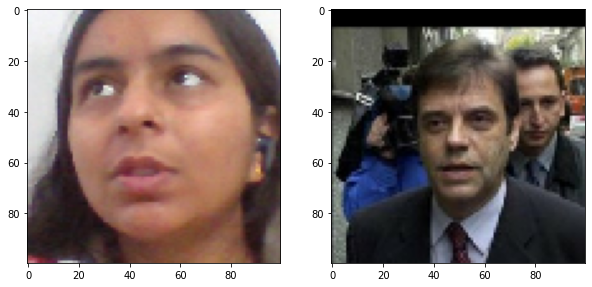

In [478]:
# Set plot size 
plt.figure(figsize=(10,8))

# Set first subplot
plt.subplot(1,2,1)
plt.imshow(test_input[0])

# Set second subplot
plt.subplot(1,2,2)
plt.imshow(test_val[0])

# Renders cleanly
plt.show()

# 7. Save Model

In [479]:
# Save weights
siamese_model.save('siamesemodelv2.h5')

In [480]:
L1Dist

__main__.L1Dist

In [498]:
siamese_model.save('siamesemodelv2_tf', save_format='tf')


INFO:tensorflow:Assets written to: siamesemodelv2_tf\assets


In [499]:
# Compile first
siamese_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# Save in HDF5 format
siamese_model.save('siamesemodelv2.h5')


In [500]:
# Make predictions with reloaded model
siamese_model.predict([test_input, test_val])

array([[1.4034349e-07],
       [9.9906659e-01],
       [8.7833385e-09],
       [9.9231414e-09],
       [8.8052399e-10],
       [1.0000000e+00],
       [2.3117998e-05]], dtype=float32)

In [501]:
# View model summary
siamese_model.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
l1_dist_15 (L1Dist)             (None, 4096)         0           embedding[0][0]     

# 8. Real Time Test

## 8.1 Verification Function

In [505]:
path = "application_data/verification_images"

In [506]:
os.listdir(os.path.join('application_data', 'verification_images'))

['d7469022-e840-11ef-a1ab-126fa62b1800.jpg',
 'd8451366-e840-11ef-833f-126fa62b1800.jpg',
 'd8774226-e840-11ef-a0ba-126fa62b1800.jpg',
 'da0b088c-e840-11ef-897f-126fa62b1800.jpg',
 'da196db6-e840-11ef-8de3-126fa62b1800.jpg',
 'da2770b8-e840-11ef-b5c1-126fa62b1800.jpg',
 'da35eed8-e840-11ef-b90c-126fa62b1800.jpg',
 'da4b1882-e840-11ef-b3df-126fa62b1800.jpg',
 'da595b9c-e840-11ef-bd67-126fa62b1800.jpg',
 'da677808-e840-11ef-b55b-126fa62b1800.jpg',
 'da75cf06-e840-11ef-8efe-126fa62b1800.jpg',
 'da84445c-e840-11ef-a33b-126fa62b1800.jpg',
 'dabd759e-e840-11ef-8f85-126fa62b1800.jpg',
 'dacbf0b6-e840-11ef-bcd8-126fa62b1800.jpg',
 'dae14e08-e840-11ef-800c-126fa62b1800.jpg',
 'daef5754-e840-11ef-8ec5-126fa62b1800.jpg',
 'dafd93f4-e840-11ef-8c8d-126fa62b1800.jpg',
 'db0ba25a-e840-11ef-9e08-126fa62b1800.jpg',
 'db1a5428-e840-11ef-9c84-126fa62b1800.jpg',
 'db28dd1a-e840-11ef-a0be-126fa62b1800.jpg',
 'db36e12e-e840-11ef-aca4-126fa62b1800.jpg',
 'db451310-e840-11ef-adb6-126fa62b1800.jpg',
 'db5378d8

In [507]:
os.path.join('application_data', 'input_image', 'input_image.jpg')

'application_data\\input_image\\input_image.jpg'

In [508]:
for image in os.listdir(os.path.join('application_data', 'verification_images')):
    validation_img = os.path.join('application_data', 'verification_images', image)
    print(validation_img)

application_data\verification_images\d7469022-e840-11ef-a1ab-126fa62b1800.jpg
application_data\verification_images\d8451366-e840-11ef-833f-126fa62b1800.jpg
application_data\verification_images\d8774226-e840-11ef-a0ba-126fa62b1800.jpg
application_data\verification_images\da0b088c-e840-11ef-897f-126fa62b1800.jpg
application_data\verification_images\da196db6-e840-11ef-8de3-126fa62b1800.jpg
application_data\verification_images\da2770b8-e840-11ef-b5c1-126fa62b1800.jpg
application_data\verification_images\da35eed8-e840-11ef-b90c-126fa62b1800.jpg
application_data\verification_images\da4b1882-e840-11ef-b3df-126fa62b1800.jpg
application_data\verification_images\da595b9c-e840-11ef-bd67-126fa62b1800.jpg
application_data\verification_images\da677808-e840-11ef-b55b-126fa62b1800.jpg
application_data\verification_images\da75cf06-e840-11ef-8efe-126fa62b1800.jpg
application_data\verification_images\da84445c-e840-11ef-a33b-126fa62b1800.jpg
application_data\verification_images\dabd759e-e840-11ef-8f85-126

In [513]:
def verify(model, detection_threshold, verification_threshold):
    # Build results array
    results = []
    for image in os.listdir(os.path.join('application_data', 'verification_images')):
        input_img = preprocess(os.path.join('application_data', 'input_image', 'input_image.jpg'))
        validation_img = preprocess(os.path.join('application_data', 'verification_images', image))
        
        # Make Predictions 
        result = model.predict(list(np.expand_dims([input_img, validation_img], axis=1)))
        results.append(result)
    
    # Detection Threshold: Metric above which a prediciton is considered positive 
    detection = np.sum(np.array(results) > detection_threshold)
    
    # Verification Threshold: Proportion of positive predictions / total positive samples 
    verification = detection / len(os.listdir(os.path.join('application_data', 'verification_images'))) 
    verified = verification > verification_threshold
    
    return results, verified

## 8.2 OpenCV Real Time Verification

In [516]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    frame = frame[120:120+250,200:200+250, :]
    
    cv2.imshow('Verification', frame)
    
    # Verification trigger
    if cv2.waitKey(10) & 0xFF == ord('v'):
        # Save input image to application_data/input_image folder 
#         hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
#         h, s, v = cv2.split(hsv)

#         lim = 255 - 10
#         v[v > lim] = 255
#         v[v <= lim] -= 10
        
#         final_hsv = cv2.merge((h, s, v))
#         img = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

        cv2.imwrite(os.path.join('application_data', 'input_image', 'input_image.jpg'), frame)
        # Run verification
        results, verified = verify(siamese_model, 0.5, 0.5)
        print(verified)
    
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

True
True
True


In [517]:
np.sum(np.squeeze(results) > 0.9)

30

In [518]:
results

[array([[0.99997747]], dtype=float32),
 array([[0.9077585]], dtype=float32),
 array([[0.1604147]], dtype=float32),
 array([[0.9735675]], dtype=float32),
 array([[0.35273573]], dtype=float32),
 array([[0.9748788]], dtype=float32),
 array([[0.9780106]], dtype=float32),
 array([[0.999988]], dtype=float32),
 array([[0.9999891]], dtype=float32),
 array([[0.99999374]], dtype=float32),
 array([[0.9999767]], dtype=float32),
 array([[0.2925024]], dtype=float32),
 array([[0.280312]], dtype=float32),
 array([[0.16668385]], dtype=float32),
 array([[0.01176551]], dtype=float32),
 array([[0.99965197]], dtype=float32),
 array([[0.9999971]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[1.]], dtype=float32),
 array([[